# 계열사 매출 × 경제지표 상관관계 (선별 7곳)

삼양그룹 계열사 14곳 중 **DART 공시에서 3년 이상 매출을 뽑을 수 있는 곳만** 골라
대시보드가 수집해 둔 경제지표(PostgreSQL)와 상관관계를 본다.

### 선별 결과 (`screen_affiliates.py`)

| 판정 | 계열사 | 사유 |
|---|---|---|
| 분석 | 삼양홀딩스 | 그룹 연결 분기 매출 (상장 000070, `RAG/fetch_dart.py`로 수집) |
| 분석 | 삼양사(식품), 삼양사(화학) | 부문별 분기 매출 18개 구간 |
| 분석 | 삼양패키징 | 법인 분기 매출 23개 구간 |
| 참고만 | 삼양이노켐, 삼양데이타시스템 | 감사보고서만 → 연간 6개 구간 |
| 제외 | 삼양엔씨켐 | 연간 5개 구간 (최소 6 미달) |
| 제외 | 삼양사(코스메틱) | 보고 부문이 식품/화학/기타뿐 — 코스메틱 매출을 뗄 수 없음 |
| 제외 | 삼남석유화학, 삼양화성, 삼양화인테크놀로지 | DART에 감사보고서 11~12건씩 있으나 아직 미수집 (연 1회) |
| 제외 | 삼양KCI, VERDANT | DART 법인 등록 자체가 확인 안 됨 |
| 제외 | 삼양바이오팜 | 2020년 1건뿐 |

### 구성
0. 환경 설정
1. 매출 시계열 로드
2. 데이터 품질 점검 — 결측치 / 이상치
3. 상관관계 (레벨 · 변화율) — 지표 135개 전부
4. 업종 큐레이션 검증
5. **추세·계절성 검증과 귀무 기준선** ← 앞 절의 상관계수를 믿어도 되는지 재는 곳
6. 시차(lag) 상관관계
7. 결론과 한계

> **먼저 읽을 것**: 3·4·6절의 상관계수를 액면 그대로 받아들이면 안 된다. 5절의 귀무 기준선에서
> **네 계열사 모두 노이즈 바닥을 넘지 못했다.** 표본이 분기 18~26개인데 지표를 119개 시험하기
> 때문이다. 결론은 7절에 정리했다.

## 0. 환경 설정

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

ROOT = Path("../..").resolve()
sys.path.append(str(ROOT / "RAG"))            # dart_parser.py
sys.path.append(str(ROOT / "dashboard" / "backend"))  # app.registry (업종별 지표 큐레이션)
sys.path.append(str(Path(".").resolve()))     # eda_utils, run_correlation

import eda_utils
import inspect_data
import run_correlation as rc

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows 기본 한글 폰트

load_dotenv(ROOT / "dashboard" / "backend" / ".env")
engine = create_engine(os.environ["DATABASE_URL"], pool_pre_ping=True)
print(f"대상 {len(rc.TARGETS)}곳:", ", ".join(t[0] for t in rc.TARGETS))

대상 7곳: 삼양홀딩스, 삼양사(식품), 삼양사(화학), 삼양패키징, 삼양엔씨켐, 삼양이노켐, 삼양데이타시스템


## 1. 매출 시계열 로드

DART XML 111건을 매번 다시 파싱하면 몇 분씩 걸려서 `out/revenue.csv`에 캐시해 둔다.
캐시가 없으면 여기서 한 번만 만든다 (`rc.load_revenue(rebuild=True)`로 강제 재생성).

- **분기**: 분·반기보고서의 누적 매출을 차분해 구간값으로 역산 (삼양홀딩스, 삼양사 부문별, 삼양패키징)
- **연간**: 감사보고서 손익계산서의 매출액 (삼양이노켐, 삼양데이타시스템, 삼양엔씨켐)

In [2]:
revenue = rc.load_revenue(rebuild=False)
revenue.groupby("label").agg(
    구간수=("revenue", "size"),
    시작=("period_to", "min"),
    종료=("period_to", "max"),
    평균매출_백만원=("revenue", "mean"),
).round(0)

매출 캐시 사용: C:\sideProject\Food_Company_Sales\mandu\Eda\out\revenue.csv (--rebuild로 재생성)


C:\Users\LouisLee(이시호)\AppData\Local\Temp\ipykernel_28524\1647225685.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round(0)


,구간수,시작,종료,평균매출_백만원
label,,,,
삼양데이타시스템,6,2020-12-31,2025-12-31,79764.0
삼양사(식품),18,2021-12-31,2026-03-31,382252.0
삼양사(화학),18,2021-12-31,2026-03-31,283116.0
삼양엔씨켐,5,2021-12-31,2025-12-31,100305.0
삼양이노켐,6,2020-12-31,2025-12-31,351976.0
삼양패키징,23,2020-09-30,2026-03-31,103144.0
삼양홀딩스,26,2020-03-31,2026-06-30,800345.0


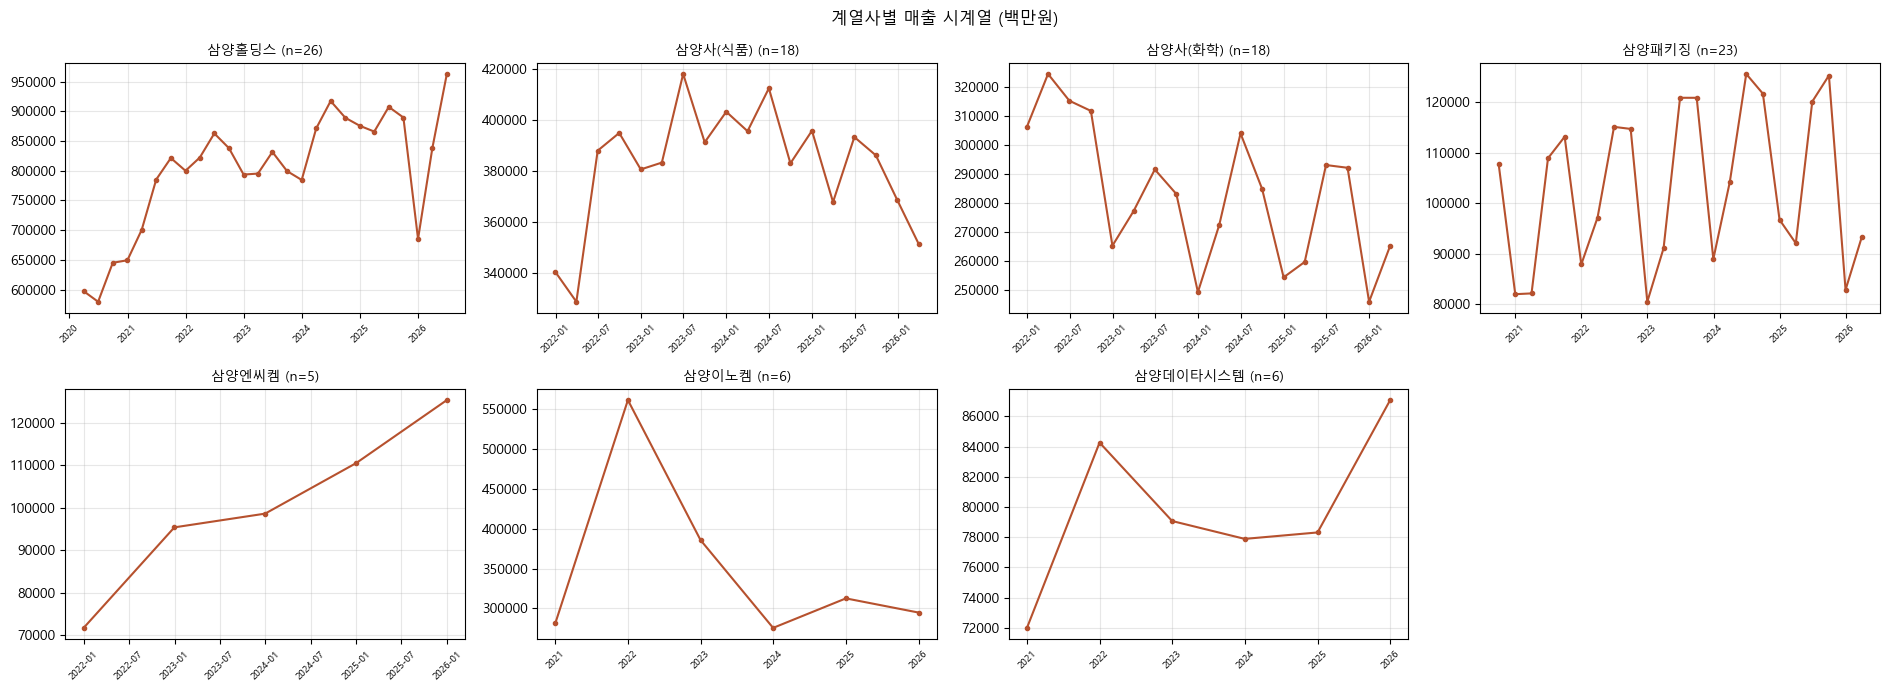

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(19, 7), sharex=False)
for ax, (label, *_) in zip(axes.flat, rc.TARGETS):
    sub = revenue[revenue.label == label]
    ax.plot(sub.period_to, sub.revenue, marker="o", ms=3, color="#B6512E")
    ax.set_title(f"{label} (n={len(sub)})", fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
for ax in axes.flat[len(rc.TARGETS):]:
    ax.axis("off")
fig.suptitle("계열사별 매출 시계열 (백만원)")
plt.tight_layout()
plt.show()

## 2. 데이터 품질 점검 — 결측치 / 이상치

이상치는 값 자체가 아니라 **전기 대비 변화량**에 MAD 기반 robust z(|z| > 5)를 씌워 잡는다.
지표 대부분이 추세를 가진 레벨 시계열이라 값에 z를 씌우면 추세 끝단이 통째로 이상치로 잡힌다.

결측 구간은 달력일이 아니라 **영업일**로 잰다 — 일별 시장지표는 주말·공휴일에 값이 없는 게 정상이라
달력일로 재면 그 공백이 전부 결측으로 잡혀 진짜 구멍이 묻힌다.

In [4]:
rev_reports = []
for label, *_ in rc.TARGETS:
    sub = revenue[revenue.label == label]
    ser = pd.Series(sub.revenue.values, index=pd.to_datetime(sub.period_to))
    rev_reports.append(inspect_data.inspect_series(f"매출::{label}", ser))

inspect_data.print_report("A. 매출 시계열", rev_reports)


A. 매출 시계열
시계열                                         빈도     n   결측   중복   0/음수   공백   이상치
------------------------------------------------------------------------------------
매출::삼양데이타시스템                                 연     6    0    0      0    0     0
매출::삼양사(식품)                                 분기    18    0    0      0    0     0
매출::삼양사(화학)                                 분기    18    0    0      0    0     0
매출::삼양엔씨켐                                    연     5    0    0      0    0     0
매출::삼양이노켐                                    연     6    0    0      0    0     0
매출::삼양패키징                                   분기    23    0    0      0    0     0
매출::삼양홀딩스                                   분기    26    0    0      0    0     0


In [5]:
with engine.connect() as conn:
    points = pd.read_sql(
        text("SELECT indicator_id, series_name, date, value FROM indicator_points"),
        conn, parse_dates=["date"],
    )

ind_reports = [
    inspect_data.inspect_series(f"{i}::{s}", g.set_index("date")["value"].sort_index())
    for (i, s), g in points.groupby(["indicator_id", "series_name"])
]
print(f"지표 시계열 {len(ind_reports)}개 · 관측치 {len(points):,}개")

# 진짜 손봐야 하는 건 "한 주기 이상 통째로 빠진" 구간뿐이라 그것만 추린다.
holed = [r for r in ind_reports if r["gaps"] and r["freq"] in ("월", "분기", "연")]
inspect_data.print_report("B. 경제지표 — 결측 구간이 있는 계열", holed)

지표 시계열 135개 · 관측치 48,256개

B. 경제지표 — 결측 구간이 있는 계열
시계열                                         빈도     n   결측   중복   0/음수   공백   이상치
------------------------------------------------------------------------------------
energy_oecd_stocks::OECD 원유 재고               월   525    0    0      0   16     5
steel_prices::냉연(천원_톤)                       월    72    0    0      0    1     7
steel_prices::후판(천원_톤)                       월    72    0    0      0    1     6
steel_prices::열연(천원_톤)                       월    72    0    0      0    1     5
steel_prices::유연탄(달러_톤)                      월    72    0    0      0    1     5
steel_prices::철근(천원_톤)                       월    72    0    0      0    1     2
steel_prices::철스크랩(달러_톤)                     월    72    0    0      0    1     2
steel_prices::철광석(달러_톤)                      월    72    0    0      0    1     1
unemployment_kr_us::미국                       월    71    0    0      0    1     1
import_price_index::미국                       월    70   

### 0/음수 값은 대부분 정상값이다

증감률·경상수지·일본 기준금리는 음수가 정상이고, WTI의 음수 1건은 2020-04-20 실제
마이너스 유가다. 자동으로 지우면 안 되므로 눈으로 확인만 한다.

In [6]:
neg = [r for r in ind_reports if r["zero_or_neg"]]
pd.DataFrame([
    {"시계열": r["name"], "빈도": r["freq"], "n": r["n"], "0이하_개수": r["zero_or_neg"]}
    for r in sorted(neg, key=lambda r: -r["zero_or_neg"])
])

,시계열,빈도,n,0이하_개수
0,ecos_monthly_macro::경상수지(서비스),월,72,69
1,policy_rates::일본,월,72,43
2,ecos_gdp_growth::건설투자,분기,24,14
3,household_income_growth::사업소득,분기,25,14
4,ecos_gdp_growth::설비투자,분기,24,11
5,household_income_growth::근로소득,분기,25,11
6,household_income_growth::처분가능소득,분기,25,9
7,ecos_monthly_macro::경상수지(계),월,72,8
8,ecos_monthly_macro::경상수지(상품),월,72,8
9,household_income_growth::소득,분기,25,6


## 3. 상관관계 (레벨 · 변화율)

**지표는 업종으로 좁히지 않고 135개 전부 본다.** 백엔드
`registry.AFFILIATE_CATEGORY_INDICATOR_CATEGORIES`의 업종별 매핑은 계열사 매출 시계열이
없던 시절 업종 상식으로 손수 정한 것이라(registry.py 주석에도 "그 데이터가 생기면 실측
상관관계로 교체하면 된다"고 적혀 있다), 그걸로 미리 걸러버리면 매핑이 맞는지 틀렸는지를
데이터로 확인할 수가 없다. 대신 각 지표가 그 큐레이션 안에 있었는지를 `큐레` 열로 표시한다.

각 매출 구간에 대해 그 구간 안 지표 값의 평균을 맞춰 정렬한 뒤,
- **레벨**: 값 그대로의 상관 — 둘 다 우상향하기만 해도 크게 나온다
- **변화율**: 전기 대비 변화율의 상관 — 추세를 걷어낸 실제 연동

두 방향이 **같은 부호**로 남고 변화율 |r| > 0.3인 지표만 신호로 본다.

In [7]:
MIN_N = 6
results = {}

all_series = {
    f"{i}::{s}": g.set_index("date")["value"].sort_index()
    for (i, s), g in points.groupby(["indicator_id", "series_name"])
}
print(f"전체 지표 시계열 {len(all_series)}개")

for label, category, *_ in rc.TARGETS:
    rev = revenue[revenue.label == label].set_index("period_to")
    curated = set(rc.indicator_ids_for(category))
    if len(rev) < MIN_N:
        print(f"{label}: 구간 {len(rev)}개뿐이라 건너뜀 (최소 {MIN_N})")
        continue

    # 매출 구간의 절반 이상 겹치는 지표만 본다. 연 1회 지표(n=6)를 26분기 매출과 맞추면
    # 6점짜리 상관이 나오는데, |r|로만 줄세우면 그게 26점짜리보다 위로 올라온다.
    min_n = max(MIN_N, len(rev) // 2)
    aligned = eda_utils.align_indicators_to_periods(rev, "revenue", all_series)
    level = eda_utils.corr_table(aligned, all_series, "revenue", min_n=min_n)
    pct = aligned.drop(columns=["period_from"]).pct_change().dropna(how="all")
    change = eda_utils.corr_table(pct, all_series, "revenue", min_n=min_n)
    results[label] = {"aligned": aligned, "level": level, "change": change,
                      "series": all_series, "n": len(rev), "min_n": min_n,
                      "curated": curated}
    n_cur = sum(1 for k in all_series if k.split("::")[0] in curated)
    print(f"{label}: 구간 {len(rev)} · 레벨 {len(level)} · 변화율 {len(change)}"
          f" · 업종 큐레이션에 있던 지표 {n_cur}/{len(all_series)}")

전체 지표 시계열 135개


삼양홀딩스: 구간 26 · 레벨 118 · 변화율 118 · 업종 큐레이션에 있던 지표 135/135


삼양사(식품): 구간 18 · 레벨 119 · 변화율 118 · 업종 큐레이션에 있던 지표 33/135


삼양사(화학): 구간 18 · 레벨 119 · 변화율 118 · 업종 큐레이션에 있던 지표 75/135


삼양패키징: 구간 23 · 레벨 119 · 변화율 118 · 업종 큐레이션에 있던 지표 38/135
삼양엔씨켐: 구간 5개뿐이라 건너뜀 (최소 6)


삼양이노켐: 구간 6 · 레벨 116 · 변화율 0 · 업종 큐레이션에 있던 지표 75/135


삼양데이타시스템: 구간 6 · 레벨 116 · 변화율 0 · 업종 큐레이션에 있던 지표 61/135


In [8]:
def top_table(label: str, top_n: int = 12) -> pd.DataFrame:
    """레벨 상관 상위 지표에 변화율 상관을 붙이고, 둘 다 같은 부호로 남으면 '견고'로 표시."""
    r = results[label]
    chg = r["change"].set_index("indicator")["pearson"].to_dict()
    rows = []
    for _, row in r["level"].head(top_n).iterrows():
        c = chg.get(row.indicator)
        rows.append({
            "지표": row.indicator,
            "레벨_r": round(row.pearson, 2),
            "변화율_r": None if c is None else round(c, 2),
            "n": row.n,
            "견고": "*" if c is not None and c * row.pearson > 0 and abs(c) > 0.3 else "",
            "큐레": "O" if row.indicator.split("::")[0] in r["curated"] else "X",
        })
    return pd.DataFrame(rows)

for label in results:
    print(f"\n{'=' * 70}\n{label}  (구간 {results[label]['n']}개)")
    display(top_table(label))


삼양홀딩스  (구간 26개)


,지표,레벨_r,변화율_r,n,견고,큐레
0,household_credit::기타금융기관 등,0.85,0.40,26,*,O
1,household_credit::상호저축은행,0.85,0.30,26,*,O
2,household_credit::가계대출,0.83,0.29,26,,O
3,household_credit::가계신용,0.83,0.26,26,,O
4,household_credit::기타금융중개회사,0.83,0.30,26,,O
5,energy_oecd_stocks::OECD 원유 재고,-0.82,-0.21,26,,O
6,fao_food_price_index::Meat,0.81,0.43,26,*,O
7,household_credit::보험회사,0.79,0.05,26,,O
8,household_credit::예금취급기관,0.77,0.16,26,,O
9,energy_oil_gas::WTI,0.77,0.58,26,*,O



삼양사(식품)  (구간 18개)


,지표,레벨_r,변화율_r,n,견고,큐레
0,fomc_dot_plot::2023,0.86,NaN,9,,X
1,fomc_dot_plot::2024,0.84,0.27,13,,X
2,policy_rates::한국,0.74,0.20,18,,X
3,household_credit::연금기금,0.73,0.18,18,,X
4,policy_rates::미국,0.71,0.63,18,*,X
5,auto_production_index::생산지수(원지수),0.69,0.66,18,*,X
6,unemployment_kr_us::한국,-0.68,-0.14,18,,O
7,household_credit::보험회사,0.66,0.13,18,,X
8,fao_food_price_index::Oils,-0.65,-0.10,18,,O
9,samyang_stock_prices::삼양사,-0.65,-0.22,18,,O



삼양사(화학)  (구간 18개)


...

,지표,레벨_r,변화율_r,n,견고,큐레
0,apartment_construction::착공_수도권,-0.39,-0.25,23,,X
1,apartment_construction::착공_계,-0.38,-0.33,23,*,X
2,fao_food_price_index::Meat,0.37,0.72,23,*,X
3,household_credit::공적금융기관,0.37,0.42,23,*,X
4,unemployment_kr_us::한국,-0.35,-0.44,23,*,X
5,rice_price::산지쌀가격(원/20kg),-0.33,-0.44,23,*,X
6,apartment_construction::착공_기타,-0.33,-0.34,23,*,X
7,household_credit::기타금융기관 등,0.32,0.43,23,*,X
8,household_credit::기타금융중개회사,0.30,0.44,23,*,X
9,fao_food_price_index::Sugar,0.29,0.16,23,,X



삼양이노켐  (구간 6개)


,지표,레벨_r,변화율_r,n,견고,큐레
0,ecos_gdp_growth::민간소비,0.94,None,6,,O
1,wood_import_prices::제재목,0.92,None,6,,O
2,wood_import_prices::PB,0.89,None,6,,O
3,steel_prices::철광석(달러_톤),0.86,None,6,,O
4,wood_import_prices::원목,0.85,None,6,,O
5,samyang_stock_prices::삼양패키징,0.83,None,6,,O
6,steel_prices::열연(천원_톤),0.79,None,6,,O
7,steel_prices::철스크랩(달러_톤),0.78,None,6,,O
8,household_credit::상호금융,0.75,None,6,,O
9,samyang_stock_prices::삼양사,0.75,None,6,,O



삼양데이타시스템  (구간 6개)


,지표,레벨_r,변화율_r,n,견고,큐레
0,market_yfinance::구리(전기동),0.94,None,6,,O
1,ecos_monthly_macro::소비자심리지수,0.94,None,6,,O
2,market_yfinance::KOSPI,0.89,None,6,,O
3,apartment_construction::준공_계,-0.87,None,6,,X
4,household_credit::예금취급기관,0.85,None,6,,O
5,household_credit::예금은행,0.78,None,6,,O
6,apartment_construction::준공_수도권,-0.78,None,6,,X
7,household_credit::가계대출,0.76,None,6,,O
8,market_yfinance::커피,0.75,None,6,,O
9,household_credit::가계신용,0.74,None,6,,O


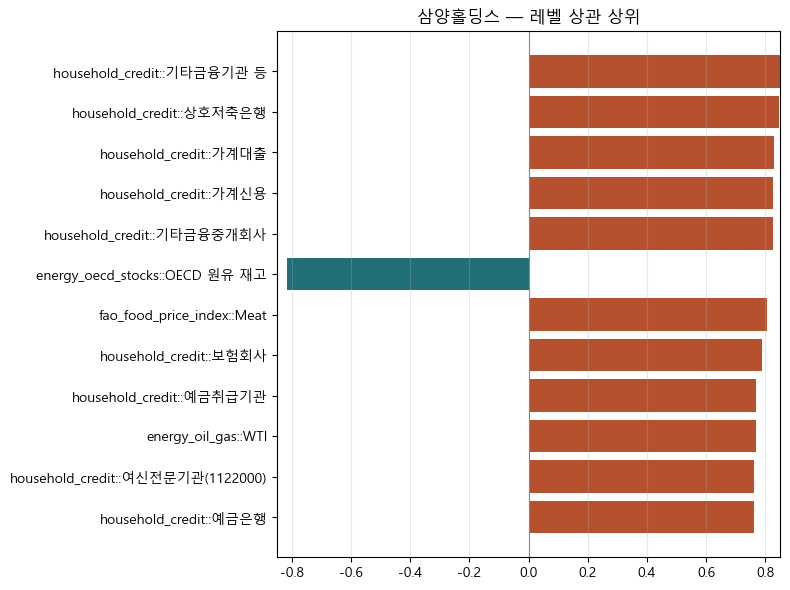

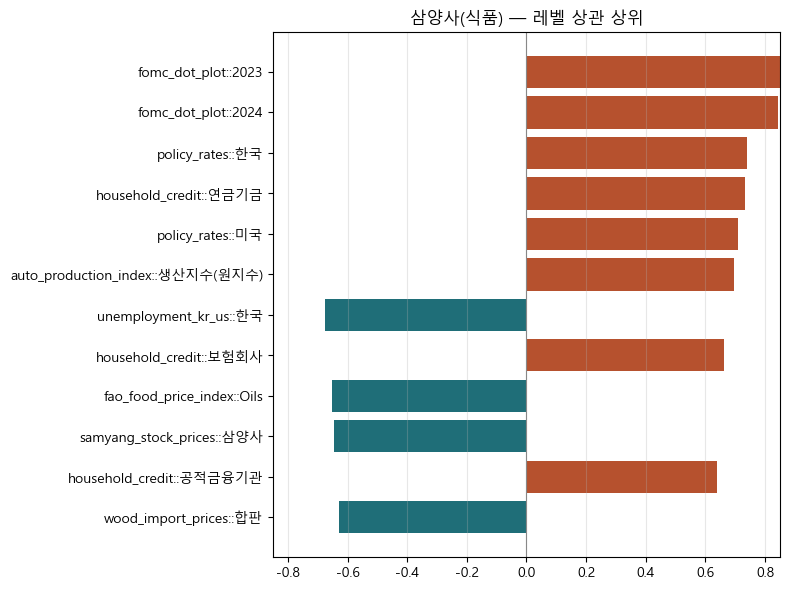

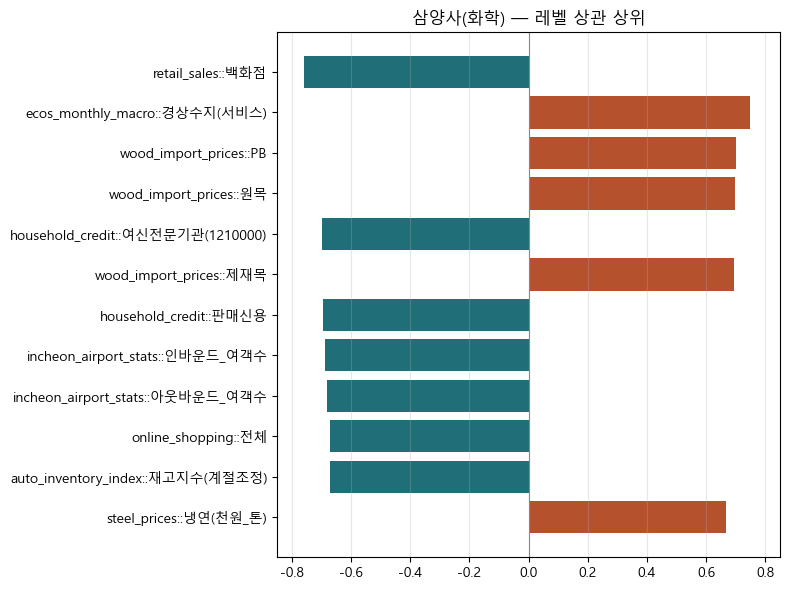

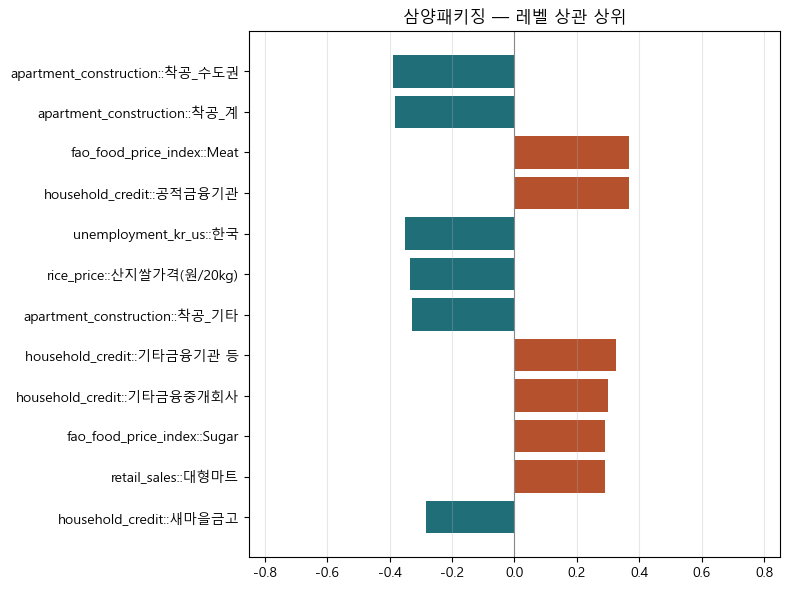

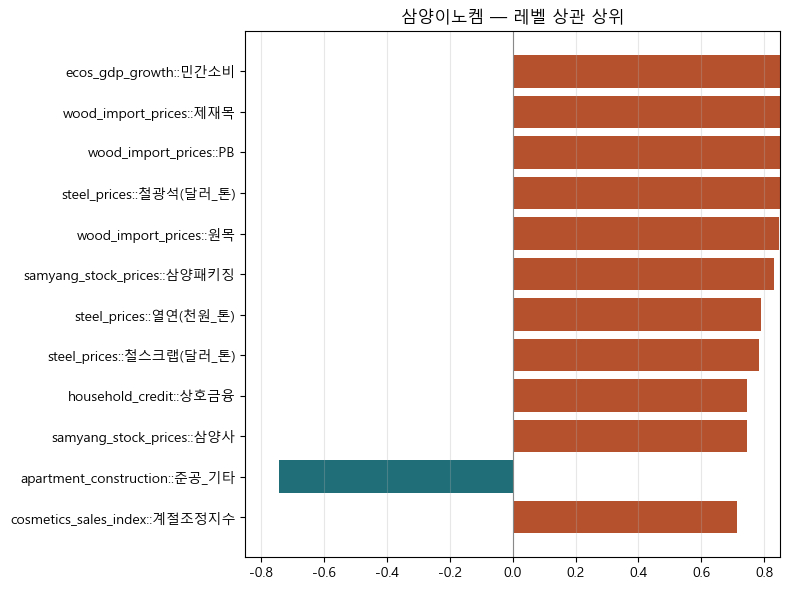

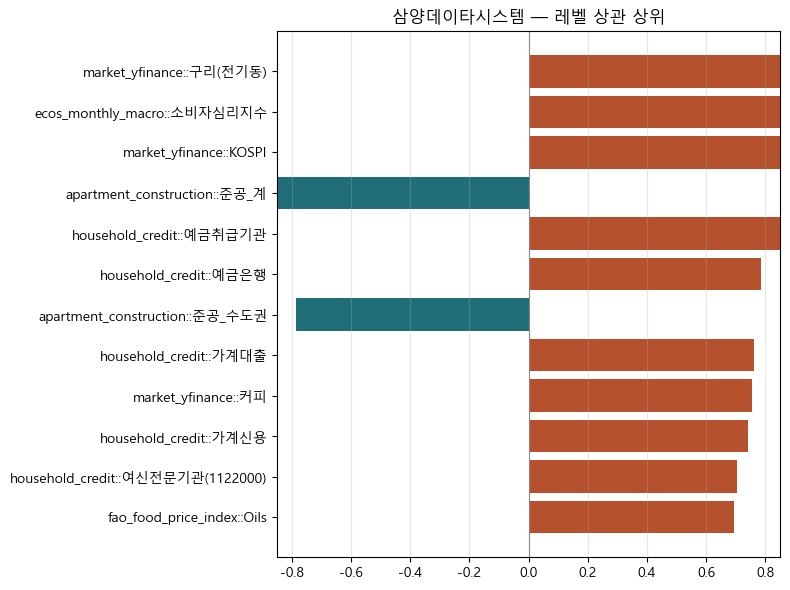

In [9]:
for label in results:
    if results[label]["level"].empty:
        continue
    eda_utils.plot_top_correlations(results[label]["level"], f"{label} — 레벨 상관 상위", top_n=12)

## 4. 업종 큐레이션 검증

`registry.py`의 업종별 지표 매핑이 위 견고 신호를 얼마나 잡아냈는지 센다.

> 이 표만 보면 "큐레이션이 신호의 절반 이상을 놓쳤으니 실측으로 교체하자"는 결론이 나오는데,
> **그 결론은 틀렸다.** 다음 절(5)의 귀무 기준선을 반드시 같이 볼 것 — 여기서 세는 "견고 신호"의
> 대부분이 노이즈와 구분되지 않는다.

In [10]:
rows = []
for label, r in results.items():
    chg = r["change"].set_index("indicator")["pearson"].to_dict()
    robust = [
        row.indicator for _, row in r["level"].iterrows()
        if (c := chg.get(row.indicator)) is not None and c * row.pearson > 0 and abs(c) > 0.3
    ]
    outside = [i for i in robust if i.split("::")[0] not in r["curated"]]
    rows.append({"계열사": label, "구간": r["n"], "견고_신호": len(robust),
                 "큐레이션_밖": len(outside),
                 "놓친_지표": ", ".join(sorted({i.split("::")[0] for i in outside}))})
pd.DataFrame(rows)

,계열사,구간,견고_신호,큐레이션_밖,놓친_지표
0,삼양홀딩스,26,28,0,
1,삼양사(식품),18,22,14,"apartment_construction, auto_inventory_index, ..."
2,삼양사(화학),18,22,13,"apartment_construction, fao_food_price_index, ..."
3,삼양패키징,23,23,16,"apartment_construction, auto_inventory_index, ..."
4,삼양이노켐,6,0,0,
5,삼양데이타시스템,6,0,0,


## 5. 추세·계절성 검증과 귀무 기준선

여기가 이 노트북에서 제일 중요한 절이다. 앞의 상관계수들을 액면 그대로 믿으면 안 되는 이유를 잰다.

**세 가지를 같이 본다.**
- `추세_r` — 지표와 시간(구간 순번)의 상관. 절댓값이 크면 그 지표는 사실상 시간의 대리변수라
  우상향하는 무엇과도 상관이 높게 나온다. 예: 가계신용은 2020년 이후 거의 단조 증가한다.
- `YoY_r` — 매출·지표를 둘 다 전년동기대비 변화율로 바꾼 뒤의 상관. 레벨 상관은 둘 다
  우상향하기만 해도 커지고, 분기 변화율(QoQ)은 매출 계절성(4분기 급증) 때문에 톱니파가 되어
  진동하는 지표와 우연히 붙는다. YoY는 추세와 계절성을 동시에 걷어낸다.
- **귀무 기준선** — 매출 시계열을 순환 이동시켜(실제 타이밍 관계는 깨고 매출 자체의 자기상관은
  보존) 같은 기준으로 생존 개수를 다시 센다. 관계가 전혀 없을 때 몇 개가 통과하는지가 노이즈
  바닥이다. 실제 생존 수가 이 바닥을 못 넘으면 생존 목록 전체를 신호로 읽으면 안 된다.

YoY는 4구간을 잃으므로 분기 12개 이상인 계열사만 검증할 수 있다.

In [11]:
NULL_THRESHOLD = 0.3


def yoy(df, lag=4):
    return (df / df.shift(lag) - 1).dropna(how="all")


verdicts, detail = [], {}
for label, r in results.items():
    values = r["aligned"].drop(columns=["period_from"])
    if len(values) < 12:
        verdicts.append({"계열사": label, "n_YoY": None, "실제_생존": None, "귀무_중앙": None,
                         "귀무_최대": None, "p": None, "판정": "검증 불가 (분기 12개 이상 필요)"})
        continue

    keys = list(r["level"].indicator)
    y4 = yoy(values)
    y = y4["revenue"]
    time_idx = pd.Series(range(len(values)), index=values.index, dtype=float)

    rows = []
    for _, row in r["level"].iterrows():
        k = row.indicator
        pair = y4[["revenue", k]].dropna()
        yoy_r = pair["revenue"].corr(pair[k]) if len(pair) >= MIN_N else float("nan")
        rows.append({
            "지표": k,
            "레벨_r": round(row.pearson, 2),
            "추세_r": round(values[k].corr(time_idx), 2),
            "YoY_r": None if pd.isna(yoy_r) else round(yoy_r, 2),
            "생존": bool(pd.notna(yoy_r) and yoy_r * row.pearson > 0 and abs(yoy_r) > NULL_THRESHOLD),
        })
    detail[label] = pd.DataFrame(rows)
    n_survived = int(detail[label]["생존"].sum())

    def count(target, keys=keys, y4=y4):
        merged = pd.concat([target.rename("_r"), y4[keys]], axis=1).dropna(how="all")
        return int((merged[keys].corrwith(merged["_r"]).abs() > NULL_THRESHOLD).sum())

    null = pd.Series([count(pd.Series(list(y.values[-k:]) + list(y.values[:-k]), index=y.index))
                      for k in range(1, len(y))])
    p = float((null >= n_survived).mean())
    verdicts.append({
        "계열사": label, "n_YoY": len(y), "실제_생존": n_survived,
        "귀무_중앙": int(null.median()), "귀무_최대": int(null.max()), "p": round(p, 2),
        "판정": "노이즈와 구분 안 됨" if p > 0.05 else "노이즈 바닥 초과",
    })

pd.DataFrame(verdicts)

,계열사,n_YoY,실제_생존,귀무_중앙,귀무_최대,p,판정
0,삼양홀딩스,22.0,56.0,52.0,77.0,0.48,노이즈와 구분 안 됨
1,삼양사(식품),14.0,77.0,60.0,82.0,0.08,노이즈와 구분 안 됨
2,삼양사(화학),14.0,68.0,63.0,77.0,0.31,노이즈와 구분 안 됨
3,삼양패키징,19.0,19.0,41.0,62.0,1.00,노이즈와 구분 안 됨
4,삼양이노켐,NaN,NaN,NaN,NaN,NaN,검증 불가 (분기 12개 이상 필요)
5,삼양데이타시스템,NaN,NaN,NaN,NaN,NaN,검증 불가 (분기 12개 이상 필요)


### 계열사별 상위 지표의 생존 여부

`추세_r`이 크면서 `YoY_r`이 무너지는 지표가 전형적인 추세 동조다.

In [12]:
for label, df in detail.items():
    print(f"{label} — 전체 {len(df)}개 중 생존 {int(df['생존'].sum())}개")
    display(df.head(15))

삼양홀딩스 — 전체 118개 중 생존 56개


,지표,레벨_r,추세_r,YoY_r,생존
0,household_credit::기타금융기관 등,0.85,0.88,0.69,True
1,household_credit::상호저축은행,0.85,0.76,0.77,True
2,household_credit::가계대출,0.83,0.91,0.76,True
3,household_credit::가계신용,0.83,0.92,0.76,True
4,household_credit::기타금융중개회사,0.83,0.89,0.55,True
5,energy_oecd_stocks::OECD 원유 재고,-0.82,-0.79,-0.57,True
6,fao_food_price_index::Meat,0.81,0.85,0.59,True
7,household_credit::보험회사,0.79,0.77,0.58,True
8,household_credit::예금취급기관,0.77,0.87,0.63,True
9,energy_oil_gas::WTI,0.77,0.42,0.81,True


삼양사(식품) — 전체 119개 중 생존 77개


,지표,레벨_r,추세_r,YoY_r,생존
0,fomc_dot_plot::2023,0.86,0.90,NaN,False
1,fomc_dot_plot::2024,0.84,0.79,0.77,True
2,policy_rates::한국,0.74,0.35,0.85,True
3,household_credit::연금기금,0.73,0.16,0.85,True
4,policy_rates::미국,0.71,0.58,0.79,True
5,auto_production_index::생산지수(원지수),0.69,0.51,0.83,True
6,unemployment_kr_us::한국,-0.68,-0.32,-0.64,True
7,household_credit::보험회사,0.66,0.21,0.76,True
8,fao_food_price_index::Oils,-0.65,-0.24,-0.77,True
9,samyang_stock_prices::삼양사,-0.65,-0.69,-0.61,True


삼양사(화학) — 전체 119개 중 생존 68개


,지표,레벨_r,추세_r,YoY_r,생존
0,retail_sales::백화점,-0.76,0.57,-0.25,False
1,ecos_monthly_macro::경상수지(서비스),0.75,-0.77,-0.65,False
2,wood_import_prices::PB,0.70,-0.77,0.81,True
3,wood_import_prices::원목,0.70,-0.85,0.70,True
4,household_credit::여신전문기관(1210000),-0.70,0.92,-0.44,True
5,wood_import_prices::제재목,0.70,-0.78,0.83,True
6,household_credit::판매신용,-0.69,0.92,-0.44,True
7,incheon_airport_stats::인바운드_여객수,-0.69,0.92,-0.83,True
8,incheon_airport_stats::아웃바운드_여객수,-0.68,0.92,-0.83,True
9,online_shopping::전체,-0.67,0.97,-0.17,False


삼양패키징 — 전체 119개 중 생존 19개


,지표,레벨_r,추세_r,YoY_r,생존
0,apartment_construction::착공_수도권,-0.39,-0.38,0.17,False
1,apartment_construction::착공_계,-0.38,-0.56,0.24,False
2,fao_food_price_index::Meat,0.37,0.80,0.21,False
3,household_credit::공적금융기관,0.37,0.76,0.58,True
4,unemployment_kr_us::한국,-0.35,-0.73,-0.28,False
5,rice_price::산지쌀가격(원/20kg),-0.33,0.05,-0.08,False
6,apartment_construction::착공_기타,-0.33,-0.67,0.32,False
7,household_credit::기타금융기관 등,0.32,0.86,0.61,True
8,household_credit::기타금융중개회사,0.30,0.87,0.49,True
9,fao_food_price_index::Sugar,0.29,0.16,0.51,True


### 같은 지표인데 계열사마다 부호가 뒤집히는가

실제 경제적 연동이라면 부호가 일관돼야 한다. 계열사마다 방향이 반대로 나오는 지표는
우연히 맞은 것으로 봐야 한다.

In [13]:
wide = pd.concat(
    {label: df.set_index("지표")["YoY_r"] for label, df in detail.items()}, axis=1
)
flip = wide.dropna(thresh=3)
flip = flip[(flip > 0).sum(axis=1).between(1, len(flip.columns) - 1)]
flip.assign(부호뒤집힘=True).sort_index().head(20)

,삼양홀딩스,삼양사(식품),삼양사(화학),삼양패키징,부호뒤집힘
지표,,,,,
apartment_construction::준공_계,0.08,0.45,-0.45,0.11,True
apartment_construction::준공_기타,0.14,0.40,-0.23,0.24,True
apartment_construction::준공_수도권,-0.01,0.27,-0.42,-0.06,True
apartment_construction::착공_계,0.20,-0.30,0.73,0.24,True
apartment_construction::착공_기타,0.29,-0.24,0.77,0.32,True
apartment_construction::착공_수도권,0.09,-0.28,0.61,0.17,True
auto_inventory_index::재고지수(계절조정),-0.70,0.73,-0.75,-0.32,True
auto_inventory_index::재고지수(원지수),-0.70,0.71,-0.74,-0.31,True
auto_production_index::생산지수(계절조정),-0.45,0.79,-0.84,-0.33,True


## 6. 시차(lag) 상관관계

지표가 t-L 구간, 매출이 t 구간일 때의 상관을 lag 0~3에 대해 계산한다.
분기 시계열이 있는 4곳만 의미가 있다 (연간 6개 구간에 lag를 걸면 표본이 3개로 줄어든다).

> 지표 × lag 조합을 모두 훑어 최댓값을 고르는 방식이라 **다중비교 문제**가 있다.
> 확정된 선행지표가 아니라 가설 후보로 취급할 것.

C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:


삼양홀딩스


,indicator,best_lag,best_corr,L0,L1,L2,L3
0,household_credit::기타금융기관 등,0,0.85,0.85,0.82,0.75,0.69
1,household_credit::상호저축은행,0,0.85,0.85,0.77,0.66,0.59
2,household_credit::가계대출,0,0.83,0.83,0.80,0.73,0.65
3,household_credit::가계신용,0,0.83,0.83,0.79,0.73,0.65
4,household_credit::기타금융중개회사,0,0.83,0.83,0.82,0.77,0.74
5,energy_oecd_stocks::OECD 원유 재고,0,-0.82,-0.82,-0.72,-0.61,-0.44
6,fao_food_price_index::Meat,0,0.81,0.81,0.63,0.51,0.50
7,household_credit::보험회사,0,0.79,0.79,0.74,0.70,0.59
8,household_credit::예금취급기관,0,0.77,0.77,0.73,0.67,0.59
9,energy_oil_gas::WTI,0,0.77,0.77,0.63,0.50,0.37


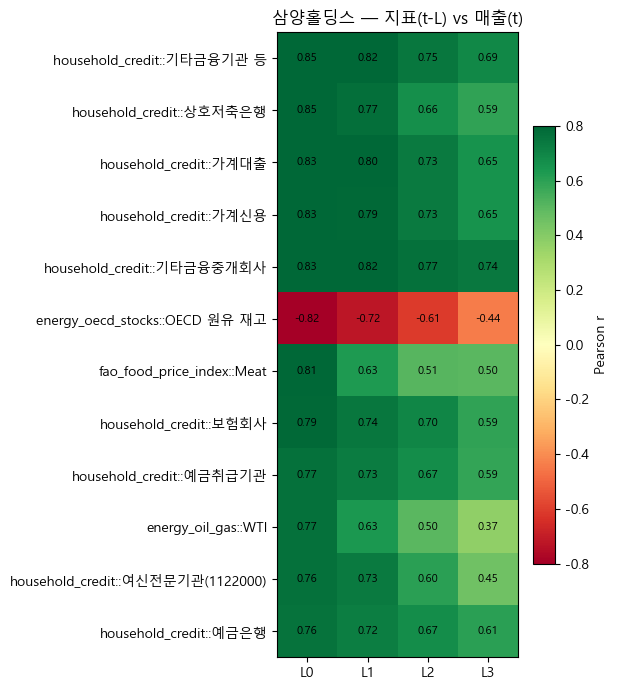

C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:


삼양사(식품)


,indicator,best_lag,best_corr,L0,L1,L2,L3
0,fomc_dot_plot::2023,0,0.86,0.86,0.76,0.48,0.32
1,fomc_dot_plot::2024,0,0.84,0.84,0.62,0.18,0.04
2,market_yfinance::구리(전기동),3,-0.78,-0.49,-0.44,-0.61,-0.78
3,apartment_construction::착공_계,1,-0.75,-0.26,-0.75,0.03,0.13
4,apartment_construction::착공_수도권,1,-0.75,-0.28,-0.75,-0.14,-0.04
5,household_credit::우체국 등,2,0.75,0.29,0.34,0.75,0.65
6,policy_rates::한국,0,0.74,0.74,0.60,0.23,0.11
7,household_credit::연금기금,0,0.73,0.73,0.64,0.39,0.28
8,fao_food_price_index::Meat,2,-0.73,-0.01,-0.27,-0.73,-0.29
9,household_credit::기타,2,-0.73,-0.31,0.02,-0.73,-0.20


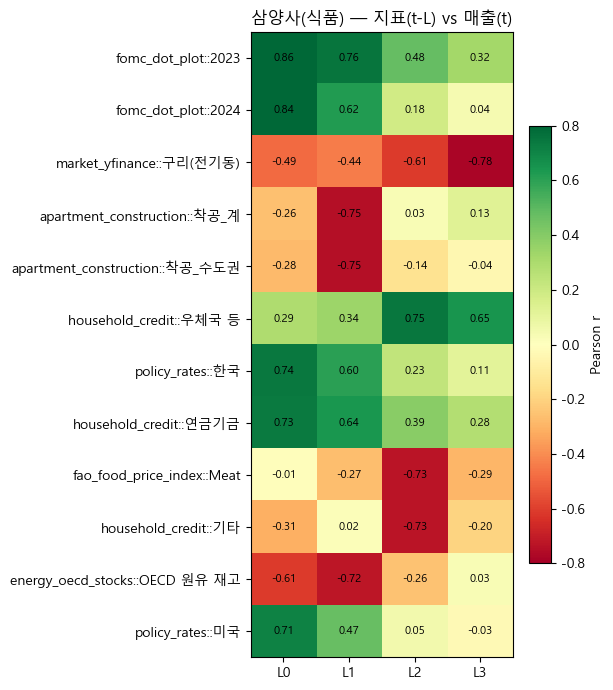

C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:


삼양사(화학)


,indicator,best_lag,best_corr,L0,L1,L2,L3
0,fomc_dot_plot::2023,1,-0.84,-0.66,-0.84,-0.62,-0.26
1,steel_prices::철스크랩(달러_톤),1,0.80,0.51,0.80,0.28,0.01
2,retail_sales::백화점,0,-0.76,-0.76,-0.21,0.07,0.09
3,ecos_monthly_macro::경상수지(서비스),0,0.75,0.75,0.56,0.37,0.32
4,household_credit::판매신용,1,-0.73,-0.69,-0.73,-0.44,-0.18
5,household_credit::여신전문기관(1210000),1,-0.72,-0.70,-0.72,-0.44,-0.17
6,fomc_dot_plot::2024,1,-0.72,-0.54,-0.72,-0.61,-0.27
7,wood_import_prices::PB,0,0.70,0.70,0.55,0.39,0.27
8,wood_import_prices::원목,0,0.70,0.70,0.65,0.24,0.27
9,wood_import_prices::제재목,0,0.70,0.70,0.64,0.40,0.33


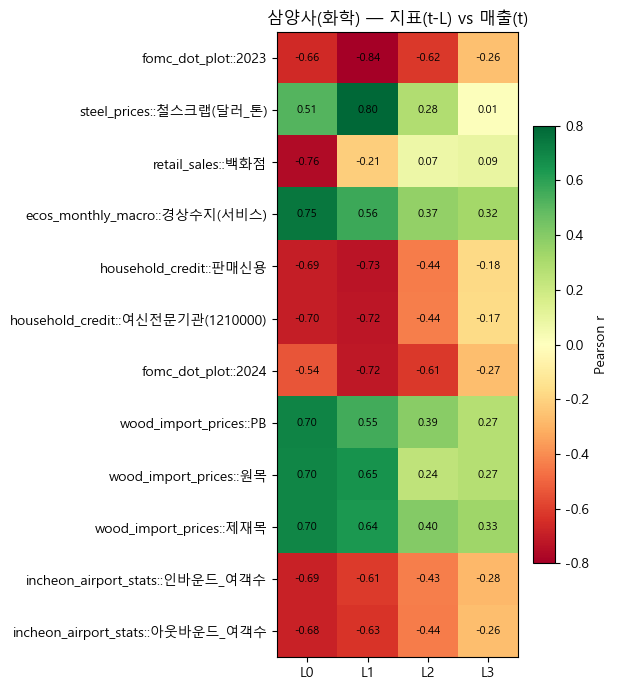


삼양패키징


C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Anaconda\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:

,indicator,best_lag,best_corr,L0,L1,L2,L3
0,apartment_construction::준공_수도권,3,0.64,-0.05,-0.22,0.08,0.64
1,apartment_construction::착공_기타,1,-0.59,-0.33,-0.59,-0.03,0.42
2,apartment_construction::착공_계,1,-0.54,-0.38,-0.54,0.01,0.36
3,apartment_construction::준공_계,3,0.54,-0.04,-0.09,0.17,0.54
4,market_yfinance::구리(전기동),3,-0.48,0.05,0.35,-0.06,-0.48
5,household_credit::판매회사,1,0.45,0.17,0.45,0.06,-0.21
6,apartment_construction::착공_수도권,1,-0.42,-0.39,-0.42,0.05,0.25
7,online_shopping::의복,2,0.40,-0.25,0.13,0.40,0.26
8,steel_prices::철스크랩(달러_톤),1,0.40,-0.01,0.40,-0.00,-0.36
9,ecos_gdp_growth::민간소비,2,-0.39,0.19,0.11,-0.39,-0.12


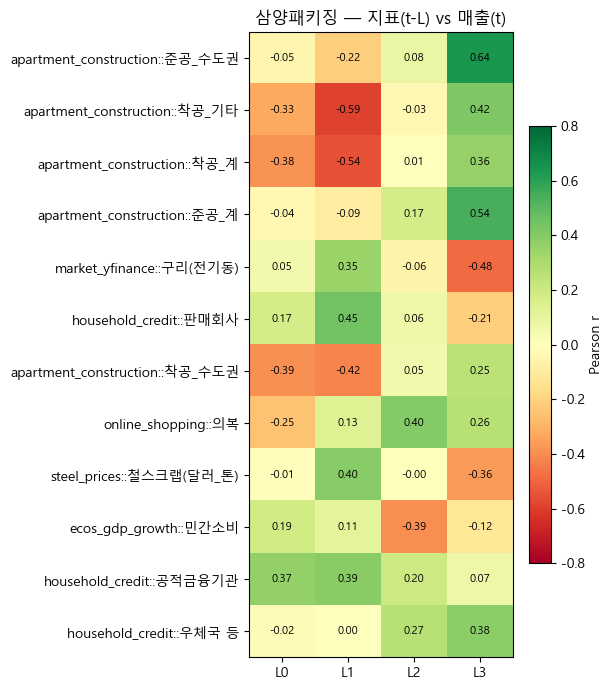

In [14]:
QUARTERLY = ["삼양홀딩스", "삼양사(식품)", "삼양사(화학)", "삼양패키징"]

for label in QUARTERLY:
    if label not in results:
        continue
    r = results[label]
    level_df = r["aligned"].drop(columns=["period_from"])
    lag_df = eda_utils.lag_correlation_table(level_df, r["series"], "revenue", max_lag=4,
                                            min_n=max(MIN_N, r["n"] // 2))
    print(f"\n{'=' * 70}\n{label}")
    display(lag_df.head(10).round(2))
    if not lag_df.empty:
        eda_utils.plot_lag_heatmap(lag_df, f"{label} — 지표(t-L) vs 매출(t)", max_lag=4, top_n=12)

## 7. 결론과 한계

### 핵심 결론: 이 상관계수들로 registry 매핑을 교체하면 안 된다

귀무 기준선(5절)이 결정적이다. 매출을 순환 이동시켜 실제 타이밍 관계를 없애도 지표 119개 중
40~60개가 "생존"으로 통과한다. 그게 노이즈 바닥이고, **네 계열사 모두 실제 생존 수가 그 바닥을
유의하게 넘지 못했다** (p = 0.08 ~ 1.00). 삼양패키징은 실제 생존(19개)이 귀무 중앙값(41개)보다
오히려 적다.

4절의 "큐레이션이 신호의 절반 이상을 놓쳤다"는 표는 그래서 **놓친 게 아니라 애초에 신호가
아니었다**로 읽어야 한다. 표본이 이 정도일 때는 큐레이션처럼 가설을 미리 좁히는 쪽이 옳다.

부호 일관성도 같은 결론을 가리킨다. `household_credit`은 삼양홀딩스에서 +, 삼양사(식품)에서 -로
방향이 뒤집힌다 (6절 마지막 표). 실제 경제적 연동이라면 나올 수 없는 패턴이다.

### 왜 이렇게 되는가
- 매출 관측치가 분기 18~26개인데 지표를 119개 시험한다. 다중비교만으로도 상당수가 통과한다.
- YoY는 4구간이 겹치는 이동창이라 자기상관이 심하다. 표본 14~22개의 유효 자유도는 그보다 훨씬 작다.
- 2020~2026 구간은 매출도 지표도 대부분 우상향한다. 레벨 상관은 이 공통 추세만으로 0.7~0.9가 나온다.

### 데이터 품질
- 매출 시계열: 결측·중복·이상치 **0건**. 다만 삼양사 부문별 매출은 2020~2021 상반기 공시의
  표 레이아웃이 달라 파싱에서 빠져 2021Q4부터 시작한다 (18개 구간).
- 경제지표: 진짜 결측은 `price_index_kr_us::미국`·`import_price_index::미국`의 2025-10,
  `steel_prices::*`의 2026-01 — 각각 한 달치. 분기 평균이 3개월 대신 2개월로 계산되는
  영향만 있어 그대로 뒀다. 메우려면 `python dashboard/backend/scripts/collect.py --force`.
- 일별 계열의 4~6영업일 공백은 추석·설 연휴, 다수의 "이상치"는 일간 가격 변동일 뿐이다.
  분기 평균으로 집계하는 순간 사라진다.

### 분석 한계
- **표본**: 분기 18~26개, 연간 6개. 연간 2곳(이노켐·데이타시스템)은 레벨 상관만 나오고
  변화율·YoY는 계산조차 안 된다. 참고용 이상으로 쓰면 안 된다.
- **레벨 상관의 함정**: 매출과 지표가 둘 다 우상향하면 인과 없이도 |r| 0.7~0.9가 나온다.
  3절의 `견고` 표시만으로는 부족하고, 5절의 `추세_r`·`YoY_r`·귀무 기준선까지 봐야 한다.
- **lag 분석(6절)은 특히 위험하다**: 지표 119개 × lag 4개를 훑어 최댓값을 고른다.
  레벨 상관조차 노이즈 바닥을 못 넘는 상황이라, 여기 나오는 선행지표는 가설 후보로도 약하다.

### 그래서 무엇을 해야 하나
1. **registry 매핑은 지금 그대로 둔다.** 업종 지식 기반 큐레이션은 이 표본 크기에서
   과적합을 막는 사전 제약으로 기능한다. 교체는 표본이 충분해진 뒤로 미룬다.
2. **표본을 늘린다.** `RAG/fetch_dart.py`로 삼양사·패키징·홀딩스 공시를 2015년부터 받으면
   분기가 26 → 44개까지 늘어난다. 그래도 119개 동시 시험은 무리다.
3. **가설을 먼저 좁힌다.** 계열사별로 업종 근거가 분명한 지표 5~10개만 사전에 정해두고
   그것만 검정하면 다중비교 부담이 사라진다. 예: 식품↔설탕·곡물, 패키징↔PET·유가.

### 다음 단계 후보
- 삼양엔씨켐: 2020~2023 감사보고서(구 "엔씨켐")에서 매출을 못 뽑은 건이 있어 구간이 5개다.
  손익계산서 파싱을 보강하면 6개 이상으로 늘릴 수 있다.
- 삼양사 부문별 매출 2020~2021 상반기: 해당 시기 표 레이아웃에 맞는 정규식을 추가하면
  구간이 18 → 23개로 늘어난다.
- 삼남석유화학·삼양화성·삼양화인테크놀로지: DART에 2015년부터 감사보고서가 11~12건씩 있다.
  `python RAG/fetch_dart.py 삼남석유화학 --type F --from 20150101` 로 받으면 연간 n=11까지
  늘릴 수 있다 (연 1회라 분기 분석은 여전히 불가).